# Neural ODE operator 

### Intuitive idea
We can view a residual neural network as the following process:$$y_{n+1} = y_n + f(y_n, \theta) \quad \forall n$$for a certain function $f$, which depends on both the state of each layer and the parameters. If we set $\Delta t = 1$, the expression above is an approximation of time step $1$ via the Euler method for the differential equation:$$\frac{dy}{dt} = f(y(t), \theta)$$Therefore, if we calculate the forward step, computing an initial state $y_0$ to a final state $y_{F}$ using the differential equation, then we will simulate a neural network with **continuous depth**.

### Rigorous Derivation of the Backward Process using Lagrangian Theory in Hilbert Spaces

To derive the gradient computation in Neural ODEs from optimal control theory, we formulate the problem within the framework of infinite-dimensional calculus of variations.

#### 1. Definition of the Functional Spaces

Let $z(t) \in \mathbb{R}^d$ be the latent state and $\theta \in \mathbb{R}^m$ the neural network parameters. To set up the problem in Hilbert spaces, we define:

*   **State Space ($\mathcal{Z}$):** For the time derivative and the weak formulation to be well-defined, the state must belong to the Sobolev space $W^{1,2}([t_0, t_1]; \mathbb{R}^d)$, frequently denoted as $H^1$. 
*   **Parameter Space ($\Theta$):** $\theta \in \mathbb{R}^m$, equipped with the standard Euclidean inner product.
*   **Constraint Space ($\mathcal{Y}$):** Assuming $f$ is Lipschitz continuous, the residual of the dynamic differential operator belongs to the space of square-integrable functions $\mathcal{Y} = L^2([t_0, t_1]; \mathbb{R}^d)$.
*   **Adjoint State Space ($\mathcal{Y}^*$):** The Lagrange multiplier (adjoint state) $a(t)$ is a continuous linear functional over $\mathcal{Y}$. By the Riesz Representation Theorem, we isometrically identify its dual space as $\mathcal{Y}^* \cong L^2([t_0, t_1]; \mathbb{R}^d)$.

#### 2. The Lagrangian Functional

The problem consists of minimizing a terminal cost function $L(z(t_1))$ subject to the dynamic constraint $E(z, \theta) = \dot{z}(t) - f(z(t), t, \theta) = 0$. 

We construct the Lagrangian functional $\mathcal{L}: \mathcal{Z} \times \Theta \times \mathcal{Y}^* \to \mathbb{R}$ by employing the dual pairing (inner product in $L^2$) between the constraint and the multiplier:

$$ \mathcal{L}(z, \theta, a) = L(z(t_1)) - \langle a, E(z, \theta) \rangle_{L^2} $$
$$ \mathcal{L}(z, \theta, a) = L(z(t_1)) - \int_{t_0}^{t_1} a(t)^\top \Big( \dot{z}(t) - f(z(t), t, \theta) \Big) dt $$

#### 3. Optimality Conditions (Fréchet Derivatives)

We seek the critical points of the Lagrangian by requiring its directional Fréchet derivatives to vanish for any admissible perturbation.

**A. Derivative with respect to the multiplier (Recovery of the Forward ODE):**
Perturbing in the direction of an arbitrary test function $\delta a \in L^2$:
$$ \partial_a \mathcal{L}[\delta a] = - \int_{t_0}^{t_1} \delta a(t)^\top \Big( \dot{z}(t) - f(z(t), t, \theta) \Big) dt = 0 \quad \forall \delta a \in L^2 $$
By the Fundamental Lemma of Calculus of Variations, this ensures that $\dot{z}(t) = f(z(t), t, \theta)$ holds almost everywhere.

**B. Derivative with respect to the state (Adjoint Equation):**
We differentiate $\mathcal{L}$ with respect to $z$ in the direction of an admissible variation $h \in H^1$ with a null initial condition $h(t_0) = 0$:
$$ \partial_z \mathcal{L}[h] = \nabla_z L(z(t_1))^\top h(t_1) - \int_{t_0}^{t_1} a(t)^\top \left( \dot{h}(t) - \frac{\partial f}{\partial z} h(t) \right) dt = 0 $$

To isolate $h(t)$, we apply integration by parts. Mathematically, this reveals the weak derivative of the functional $a(t)$, promoting it via a gain of regularity from the $L^2$ space to the Sobolev space $H^1$:
$$ \int_{t_0}^{t_1} a(t)^\top \dot{h}(t) dt = a(t_1)^\top h(t_1) - \underbrace{a(t_0)^\top h(t_0)}_{=0} - \int_{t_0}^{t_1} \dot{a}(t)^\top h(t) dt $$

Substituting this into the variational equation and grouping the terms associated with $h(t)$ and $h(t_1)$:
$$ 0 = \left( \nabla_z L(z(t_1)) - a(t_1) \right)^\top h(t_1) + \int_{t_0}^{t_1} \left( \dot{a}(t)^\top + a(t)^\top \frac{\partial f}{\partial z} \right) h(t) dt $$

Since $h(t)$ and the boundary value $h(t_1)$ are independent, their coefficients must vanish, thereby defining the full dynamics of the adjoint state:
1. **Transversality condition:** $a(t_1) = \nabla_z L(z(t_1))$
2. **Adjoint differential equation:** $\dot{a}(t) = - \left( \frac{\partial f}{\partial z} \right)^\top a(t)$

**C. Derivative with respect to parameters (Gradient Computation):**
Finally, we evaluate the Fréchet derivative of the Lagrangian with respect to $\theta$ in the direction $\delta \theta \in \mathbb{R}^m$, assuming the optimality conditions for $z$ and $a$ are already satisfied:
$$ \partial_\theta \mathcal{L}[\delta \theta] = \int_{t_0}^{t_1} a(t)^\top \frac{\partial f}{\partial \theta} \delta \theta dt $$

From this linear expression, we extract the exact gradient vector $\nabla_\theta L$ that will be propagated to the optimizer (e.g., Adam or SGD):
$$ \nabla_\theta L = \int_{t_0}^{t_1} \left( \frac{\partial f}{\partial \theta} \right)^\top a(t) dt $$

**Algorithm** Reverse-mode derivative of an ODE initial value problem

---

**Input:** dynamics parameters $\theta$, start time $t_0$, stop time $t_1$, final state $\mathbf{z}(t_1)$, loss gradient $\partial L/\partial \mathbf{z}(t_1)$

$s_0 = \left[\mathbf{z}(t_1), \frac{\partial L}{\partial \mathbf{z}(t_1)}, \mathbf{0}_{\vert{}\theta\vert{}}\right]$ $\quad \triangleright$ Define initial augmented state

** Backward process **

---

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchdiffeq import odeint
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Configurar reproducibilidad
torch.manual_seed(42)
np.random.seed(42)

Datos generados:
  X shape: (600, 2)
  y shape: (600,)
  Clase 0: 300 muestras
  Clase 1: 300 muestras


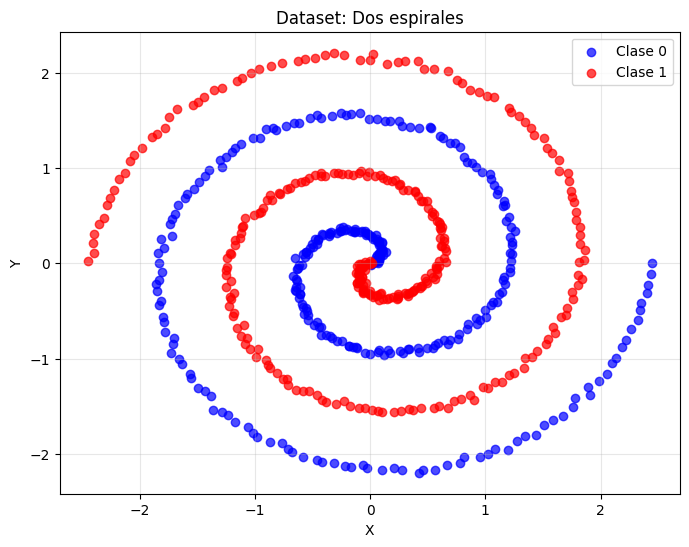

In [2]:
# ============================================
# 2.1 GENERAR DATOS
# ============================================

def generate_spiral_data(n_points=300, noise=0.1):
    # Espiral 1 (clase 0)
    t = np.linspace(0, 4*np.pi, n_points)
    x1 = t * np.cos(t) + np.random.randn(n_points) * noise
    y1 = t * np.sin(t) + np.random.randn(n_points) * noise
    
    # Espiral 2 (clase 1) - desplazada y rotada
    x2 = t * np.cos(t + np.pi) + np.random.randn(n_points) * noise
    y2 = t * np.sin(t + np.pi) + np.random.randn(n_points) * noise
    
    # Combinar
    X = np.vstack([np.column_stack([x1, y1]), np.column_stack([x2, y2])])
    y = np.hstack([np.zeros(n_points), np.ones(n_points)])
    
    # Normalizar
    X = (X - X.mean(axis=0)) / X.std(axis=0)
    
    return X.astype(np.float32), y.astype(np.int64)

# Generar datos
X, y = generate_spiral_data(n_points=300, noise=0.1)

print(f"Datos generados:")
print(f"  X shape: {X.shape}")
print(f"  y shape: {y.shape}")
print(f"  Clase 0: {sum(y==0)} muestras")
print(f"  Clase 1: {sum(y==1)} muestras")

# ============================================
# 2.2 VISUALIZAR DATOS
# ============================================

plt.figure(figsize=(8, 6))
plt.scatter(X[y==0, 0], X[y==0, 1], c='blue', alpha=0.7, label='Clase 0')
plt.scatter(X[y==1, 0], X[y==1, 1], c='red', alpha=0.7, label='Clase 1')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Dataset: Dos espirales')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [3]:
# ============================================
# 3.1 DEFINIR DATASET
# ============================================

class SpiralDataset(Dataset):
    """
    Dataset simple para las espirales.
    """
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# ============================================
# 3.2 DIVIDIR EN TRAIN Y TEST
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {len(X_train)} muestras")
print(f"Test: {len(X_test)} muestras")

# ============================================
# 3.3 CREAR DATALOADERS
# ============================================

train_dataset = SpiralDataset(X_train, y_train)
test_dataset = SpiralDataset(X_test, y_test)

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

Train: 480 muestras
Test: 120 muestras


In [4]:
# ============================================
# 4.1 FUNCIÓN DE DINÁMICA DE LA ODE
# ============================================

class ODEFunc(nn.Module):
    """
    Define dh/dt = f(h, t)
    
    Esta red aprende la dinámica del estado latente.
    """
    def __init__(self, hidden_dim):
        super(ODEFunc, self).__init__()
        
        self.net = nn.Sequential(
            nn.Linear(hidden_dim, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, hidden_dim)
        )
        
        # Inicialización para estabilidad
        self._initialize_weights()
    
    def _initialize_weights(self):
        for m in self.net.modules():
            if isinstance(m, nn.Linear):
                nn.init.orthogonal_(m.weight, gain=0.5)
                nn.init.constant_(m.bias, val=0)
    
    def forward(self, t, h):
        """
        Args:
            t: tiempo (escalar)
            h: estado latente [batch_size, hidden_dim]
        
        Returns:
            dh/dt: [batch_size, hidden_dim]
        """
        return self.net(h)

# ============================================
# 4.2 MODELO COMPLETO
# ============================================

class NeuralODE_Classifier(nn.Module):
    """
    Modelo Neural ODE para clasificación.
    
    Arquitectura:
    1. Encoder: (x, y) -> h(0)
    2. ODE: h(0) -> h(T) (evolución en el tiempo)
    3. Classifier: h(T) -> logits (clase)
    """
    def __init__(self, input_dim=2, hidden_dim=64, num_classes=2, solver='dopri5'):
        super(NeuralODE_Classifier, self).__init__()
        
        self.hidden_dim = hidden_dim
        self.solver = solver
        
        # 1. ENCODER: (x, y) -> estado latente inicial
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, hidden_dim),
            nn.Tanh()
        )
        
        # 2. ODE: dh/dt = f(h, t)
        self.ode_func = ODEFunc(hidden_dim)
        
        # 3. CLASSIFIER: h(T) -> logits
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, 32),
            nn.ReLU(),
            nn.Linear(32, num_classes)
        )
    
    def forward(self, x, t_eval):
        """
        Args:
            x: [batch_size, input_dim] (punto inicial)
            t_eval: [num_times] (tiempos de evaluación)
        
        Returns:
            logits: [batch_size, num_classes]
            h_t: [num_times, batch_size, hidden_dim]
        """
        # 1. Codificar estado inicial
        h0 = self.encoder(x)  # [batch_size, hidden_dim]
        
        # 2. Resolver la ODE
        h_t = odeint(
            self.ode_func,
            h0,
            t_eval,
            method=self.solver,
            rtol=1e-3,
            atol=1e-4
        )  # [num_times, batch_size, hidden_dim]
        
        # 3. Tomar el estado final
        h_final = h_t[-1]  # [batch_size, hidden_dim]
        
        # 4. Clasificar
        logits = self.classifier(h_final)  # [batch_size, num_classes]
        
        return logits, h_t

In [5]:
# ============================================
# 5.1 FUNCIÓN DE ENTRENAMIENTO
# ============================================

def train_epoch(model, dataloader, optimizer, loss_fn, device, t_eval):
    """
    Entrena una época.
    
    Returns:
        avg_loss: pérdida promedio
        accuracy: exactitud (%)
    """
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    for batch_idx, (X, y) in enumerate(dataloader):
        X = X.to(device)
        y = y.to(device)
        
        # Forward pass
        logits, _ = model(X, t_eval)
        loss = loss_fn(logits, y)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        # Estadísticas
        total_loss += loss.item()
        _, predicted = logits.max(1)
        total += y.size(0)
        correct += predicted.eq(y).sum().item()
    
    avg_loss = total_loss / len(dataloader)
    accuracy = 100. * correct / total
    
    return avg_loss, accuracy

# ============================================
# 5.2 FUNCIÓN DE EVALUACIÓN
# ============================================

def evaluate(model, dataloader, loss_fn, device, t_eval):
    """
    Evalúa el modelo.
    
    Returns:
        avg_loss: pérdida promedio
        accuracy: exactitud (%)
    """
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for X, y in dataloader:
            X = X.to(device)
            y = y.to(device)
            
            logits, _ = model(X, t_eval)
            loss = loss_fn(logits, y)
            
            total_loss += loss.item()
            _, predicted = logits.max(1)
            total += y.size(0)
            correct += predicted.eq(y).sum().item()
    
    avg_loss = total_loss / len(dataloader)
    accuracy = 100. * correct / total
    
    return avg_loss, accuracy


In [ ]:
# ============================================
# 6.1 CONFIGURACIÓN
# ============================================

# Device
device = torch.device("cuda")

# Crear modelo
model = NeuralODE_Classifier(
    input_dim=2,
    hidden_dim=64,
    num_classes=2,
    solver='dopri5'  # También puedes usar 'rk4' para más velocidad
).to(device)


# Optimizador y pérdida
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.CrossEntropyLoss()

# Tiempos de evaluación (de 0 a 1)
t_eval = torch.linspace(0, 1, 20).to(device)

# ============================================
# 6.2 ENTRENAMIENTO
# ============================================

num_epochs = 50
history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}

print("\n" + "=" * 60)
print("INICIO DEL ENTRENAMIENTO")
print("=" * 60)

for epoch in range(num_epochs):
    # Entrenar
    train_loss, train_acc = train_epoch(
        model, train_loader, optimizer, loss_fn, device, t_eval
    )
    
    # Evaluar
    test_loss, test_acc = evaluate(
        model, test_loader, loss_fn, device, t_eval
    )
    
    # Guardar historial
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['test_loss'].append(test_loss)
    history['test_acc'].append(test_acc)
    
    # Imprimir progreso
    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Época {epoch+1:3d}/{num_epochs} | "
              f"Train Loss: {train_loss:.4f} | "
              f"Train Acc: {train_acc:.2f}% | "
              f"Test Acc: {test_acc:.2f}%")

print("\n" + "=" * 60)
print("ENTRENAMIENTO COMPLETADO ✅")
print("=" * 60)

# Resultados finales
final_train_acc = history['train_acc'][-1]
final_test_acc = history['test_acc'][-1]
print(f"Exactitud final en Train: {final_train_acc:.2f}%")
print(f"Exactitud final en Test:  {final_test_acc:.2f}%")

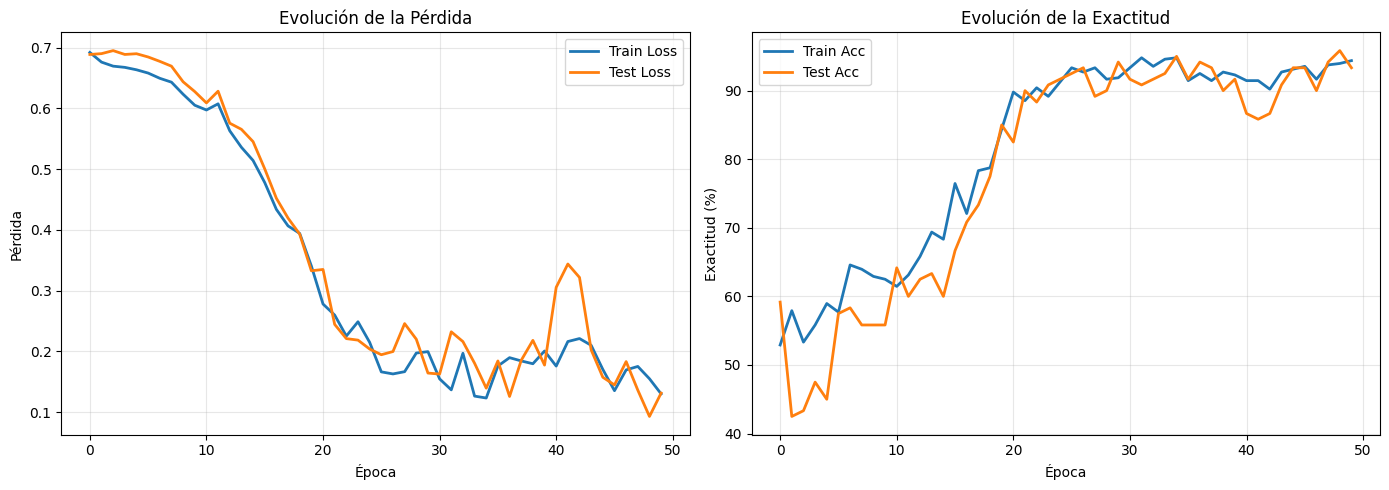

In [ ]:
# ============================================
# 7.1 CURVAS DE APRENDIZAJE
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pérdida
axes[0].plot(history['train_loss'], label='Train Loss', linewidth=2)
axes[0].plot(history['test_loss'], label='Test Loss', linewidth=2)
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Pérdida')
axes[0].set_title('Evolución de la Pérdida')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Exactitud
axes[1].plot(history['train_acc'], label='Train Acc', linewidth=2)
axes[1].plot(history['test_acc'], label='Test Acc', linewidth=2)
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Exactitud (%)')
axes[1].set_title('Evolución de la Exactitud')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()




In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchdiffeq import odeint_adjoint as odeint
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt


In [5]:
import torch
device = (
    "cuda" if torch.cuda.is_available()
    else "cpu"
)
print(f"Usando {device}")

import io
import zipfile
from pathlib import Path

import numpy as np
from scipy.io import loadmat

try:
    from sklearn.preprocessing import LabelEncoder
except ModuleNotFoundError:
    class LabelEncoder:
        """Equivalente minimo al de sklearn, por si no esta instalado."""

        def fit_transform(self, y):
            self.classes_, codigos = np.unique(y, return_inverse=True)
            return codigos

        def transform(self, y):
            return np.searchsorted(self.classes_, y)

        def inverse_transform(self, codigos):
            return self.classes_[np.asarray(codigos)]

# En un script existe __file__; en un notebook no, ahi se usa el directorio actual.
_BASE = Path(__file__).resolve().parent if "__file__" in globals() else Path.cwd()
RUTA_ZIP = _BASE / "character_trajectories" / "character_trajectories.zip"


def cargar_datos(ruta_zip=RUTA_ZIP):
    """Lee el .mat directamente desde el zip local, sin descargar nada.

    Devuelve:
        trajectories:  lista de 2858 arrays (T_i, 3) con columnas [t, x, y];
                       x e y son posiciones (velocidades integradas) escaladas a [-1, 1]
        labels:        array (N,) con el codigo entero de cada caracter
        label_encoder: LabelEncoder ajustado, label_encoder.classes_ da las 20 letras
    """
    with zipfile.ZipFile(ruta_zip) as z:
        nombre = next(n for n in z.namelist() if n.endswith(".mat"))
        mat = loadmat(io.BytesIO(z.read(nombre)))

    mixout = mat["mixout"][0]                       # 2858 secuencias (3, T)
    consts = mat["consts"][0, 0]
    key = np.array([str(k[0]) for k in consts["key"][0]])
    etiquetas = key[consts["charlabels"][0] - 1]    # indices MATLAB: 1-based
    dt = float(consts["dt"][0, 0])                  # 0.005 s

    trajectories = []
    for seq in mixout:
        x = np.cumsum(seq[0]) * dt                  # integrar velocidades -> posicion
        y = np.cumsum(seq[1]) * dt
        x = (x - x.min()) / (x.max() - x.min() + 1e-8) * 2 - 1
        y = (y - y.min()) / (y.max() - y.min() + 1e-8) * 2 - 1
        t = np.arange(len(x)) * dt
        trajectories.append(np.column_stack([t, x, y]))

    le = LabelEncoder()
    encoded = le.fit_transform(etiquetas)
    print(f"Total de trayectorias: {len(trajectories)}")
    print(f"Clases ({len(le.classes_)}): {le.classes_}")
    return trajectories, encoded, le


def a_tensores(trajectories, labels, device=device):
    """Rellena las secuencias a la longitud maxima y las pasa a torch.

    Devuelve x (N, T_max, 3) con columnas [t, x, y], mascara (N, T_max) con
    True en los pasos reales, longitudes (N,) e y (N,).
    """
    n = len(trajectories)
    longitudes = np.array([len(t) for t in trajectories])
    t_max = int(longitudes.max())

    x = np.zeros((n, t_max, 3), dtype=np.float32)
    mascara = np.zeros((n, t_max), dtype=bool)
    for i, t in enumerate(trajectories):
        x[i, : len(t)] = t
        mascara[i, : len(t)] = True

    return (
        torch.from_numpy(x).to(device),
        torch.from_numpy(mascara).to(device),
        torch.from_numpy(longitudes).to(device),
        torch.from_numpy(np.asarray(labels, dtype=np.int64)).to(device),
    )


if __name__ == "__main__":
    trajectories, labels, label_encoder = cargar_datos()
    x, mascara, longitudes, y = a_tensores(trajectories, labels)

    print(f"x: {tuple(x.shape)}  mascara: {tuple(mascara.shape)}  y: {tuple(y.shape)}")
    print(f"longitud min/media/max: {longitudes.min()} / {longitudes.float().mean():.1f} / {longitudes.max()}")
    print(f"primera muestra: caracter '{label_encoder.classes_[labels[0]]}', {longitudes[0]} pasos")


Usando cuda
Total de trayectorias: 2858
Clases (20): ['a' 'b' 'c' 'd' 'e' 'g' 'h' 'l' 'm' 'n' 'o' 'p' 'q' 'r' 's' 'u' 'v' 'w'
 'y' 'z']
x: (2858, 205, 3)  mascara: (2858, 205)  y: (2858,)
longitud min/media/max: 109 / 170.5 / 205
primera muestra: caracter 'a', 178 pasos


In [8]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import os
import urllib.request
import zipfile
from pathlib import Path

# Configuración
DATA_DIR = Path("./character_trajectories")
DATA_DIR.mkdir(exist_ok=True)

In [11]:
import urllib.request, zipfile
from pathlib import Path
import numpy as np
import scipy.io as sio
from sklearn.preprocessing import LabelEncoder

URL = "https://archive.ics.uci.edu/static/public/175/character+trajectories.zip"

def download_uci_character_dataset():
    DATA_DIR.mkdir(parents=True, exist_ok=True)
    zip_path = DATA_DIR / "character_trajectories.zip"
    mat_path = DATA_DIR / "mixoutALL_shifted.mat"

    if not mat_path.exists():
        if not zip_path.exists():
            print("Descargando dataset...")
            req = urllib.request.Request(URL, headers={"User-Agent": "Mozilla/5.0"})
            with urllib.request.urlopen(req, timeout=60) as r:
                zip_path.write_bytes(r.read())
        with zipfile.ZipFile(zip_path) as z:
            z.extractall(DATA_DIR)
        print("Archivos extraídos.")
    return mat_path

def load_character_trajectories(mat_path):
    mat = sio.loadmat(mat_path)
    mixout = mat["mixout"][0]                       # 2858 secuencias (3, T)
    consts = mat["consts"][0, 0]
    key = np.array([str(k[0]) for k in consts["key"][0]])
    labels = key[consts["charlabels"][0] - 1]       # índices MATLAB: 1-based
    dt = float(consts["dt"][0, 0])                  # 0.005 s

    trajectories = []
    for seq in mixout:
        x = np.cumsum(seq[0]) * dt                  # integrar velocidades -> posición
        y = np.cumsum(seq[1]) * dt
        x = (x - x.min()) / (x.max() - x.min() + 1e-8) * 2 - 1
        y = (y - y.min()) / (y.max() - y.min() + 1e-8) * 2 - 1
        t = np.arange(len(x)) * dt
        trajectories.append(np.column_stack([t, x, y]))

    le = LabelEncoder()
    encoded = le.fit_transform(labels)
    print(f"Total de trayectorias: {len(trajectories)}")
    print(f"Clases ({len(le.classes_)}): {le.classes_}")
    return trajectories, encoded, le

data_path = download_uci_character_dataset()
trajectories, labels, label_encoder = load_character_trajectories(data_path)

Descargando dataset...
Archivos extraídos.
Total de trayectorias: 2858
Clases (20): ['a' 'b' 'c' 'd' 'e' 'g' 'h' 'l' 'm' 'n' 'o' 'p' 'q' 'r' 's' 'u' 'v' 'w'
 'y' 'z']


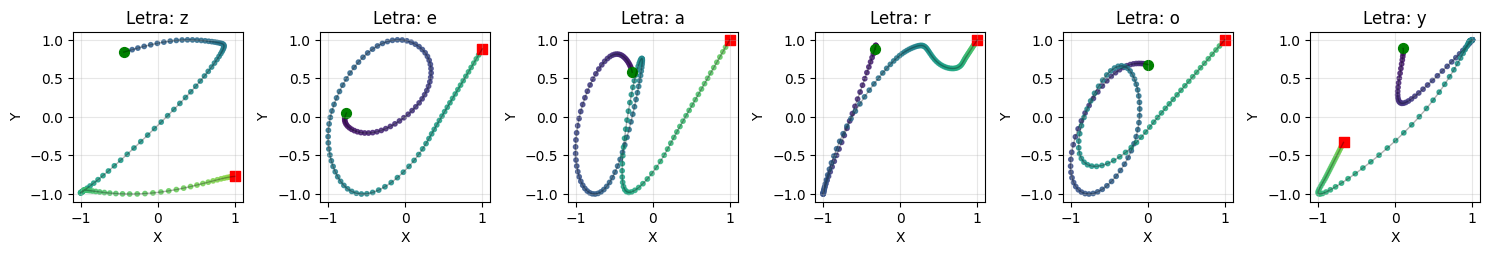

In [6]:
def plot_trajectories(trajectories, labels, label_encoder, num_samples=5):
    """Visualiza varias trayectorias de muestra"""
    fig, axes = plt.subplots(1, num_samples, figsize=(15, 3))
    
    # Seleccionar muestras aleatorias
    indices = np.random.choice(len(trajectories), num_samples, replace=False)
    
    for idx, ax in enumerate(axes):
        traj = trajectories[indices[idx]]
        label = label_encoder.inverse_transform([labels[indices[idx]]])[0]
        
        # Extraer datos
        t = traj[:, 0]
        x = traj[:, 1]
        y = traj[:, 2]
        
        # Graficar trayectoria con gradiente de tiempo
        scatter = ax.scatter(x, y, c=t, cmap='viridis', s=10, alpha=0.8)
        ax.plot(x, y, 'k-', alpha=0.3, linewidth=1)
        ax.set_title(f'Letra: {label}')
        ax.set_xlabel('X')
        ax.set_ylabel('Y')
        ax.set_aspect('equal')
        ax.grid(True, alpha=0.3)
        
        # Punto inicial y final
        ax.scatter(x[0], y[0], c='green', s=50, marker='o', label='Inicio')
        ax.scatter(x[-1], y[-1], c='red', s=50, marker='s', label='Fin')
    
    plt.tight_layout()
    plt.show()

# Visualizar algunas trayectorias
plot_trajectories(trajectories, labels, label_encoder, num_samples=6)

In [7]:
device = torch.device("cuda")
print(device)

cuda


Como cada letra tarda un tiempo distinto en dibujarse, los tensores tienen diferentes dimensiones $T_i$. PyTorch requiere tensores rectangulares para procesar datos en paralelo. Utilizamos pad_sequence para rellenar las trayectorias cortas con ceros hasta igualar la longitud de la trayectoria más larga del lote.

In [8]:
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import numpy as np

# ============================================
# 1. CONFIGURACIÓN INICIAL
# ============================================

# Semilla para reproducibilidad
np.random.seed(42)
torch.manual_seed(42)
# ============================================
# 2. DATASET
# ============================================

class TrajectoryDataset(Dataset):
    """
    Dataset para trayectorias de escritura
    
    Cada muestra es una trayectoria con forma [n_puntos, 3] donde:
    - columna 0: tiempo (t)
    - columna 1: coordenada x
    - columna 2: coordenada y
    """
    def __init__(self, trajectories, labels, max_points=200, normalize=True):
        """
        Args:
            trajectories: lista de arrays [T, 3] con (t, x, y)
            labels: array de etiquetas (números enteros)
            max_points: máximo de puntos por trayectoria (muestreo)
            normalize: normalizar coordenadas a [-1, 1]
        """
        self.trajectories = []
        self.labels = []
        
        for traj, label in zip(trajectories, labels):
            # Extraer columnas
            t = traj[:, 0]
            x = traj[:, 1]
            y = traj[:, 2]
            
            # Muestrear si es muy larga
            if len(t) > max_points:
                indices = np.linspace(0, len(t) - 1, max_points, dtype=int)
                t = t[indices]
                x = x[indices]
                y = y[indices]
            
            # Normalizar coordenadas a [-1, 1]
            if normalize:
                x = 2 * (x - x.min()) / (x.max() - x.min() + 1e-8) - 1
                y = 2 * (y - y.min()) / (y.max() - y.min() + 1e-8) - 1
            
            # Convertir a tensor [n_puntos, 3] con (t, x, y)
            traj_tensor = torch.tensor(np.column_stack([t, x, y]), dtype=torch.float32)
            
            self.trajectories.append(traj_tensor)
            self.labels.append(torch.tensor(label, dtype=torch.long))
    
    def __len__(self):
        return len(self.trajectories)
    
    def __getitem__(self, idx):
        return self.trajectories[idx], self.labels[idx]

# ============================================
# 3. COLLATE FUNCTION
# ============================================

def collate_fn_with_lengths(batch):
    """
    Agrupa un batch de trayectorias con padding.
    
    Args:
        batch: lista de tuplas (trajectory, label)
    
    Returns:
        observations_padded: [batch_size, max_len, 2] (x, y) con padding
        times_padded: [batch_size, max_len] (t) con padding
        labels: [batch_size]
        lengths: [batch_size] longitudes reales de cada secuencia
    """
    trajectories, labels = zip(*batch)
    
    batch_size = len(trajectories)
    
    # Calcular longitudes reales
    lengths = torch.tensor([len(traj) for traj in trajectories], dtype=torch.long)
    max_len = lengths.max().item()
    
    # Crear tensores con padding
    observations_padded = torch.zeros(batch_size, max_len, 2, dtype=torch.float32)
    times_padded = torch.zeros(batch_size, max_len, dtype=torch.float32)
    
    for i, traj in enumerate(trajectories):
        length = lengths[i].item()
        # traj: [n_puntos, 3] -> [t, x, y]
        observations_padded[i, :length, :] = traj[:, 1:]  # (x, y)
        times_padded[i, :length] = traj[:, 0]             # (t)
    
    # Stackear etiquetas
    labels = torch.stack(labels)
    
    return observations_padded, times_padded, labels, lengths

# ============================================
# 4. DIVISIÓN DE DATOS
# ============================================

def prepare_ode_data(trajectories, labels, test_size=0.2, val_size=0.15, random_state=42):
    """
    Divide los datos en entrenamiento, validación y prueba.
    
    Args:
        trajectories: lista de arrays [T, 3]
        labels: array de etiquetas
        test_size: proporción para prueba
        val_size: proporción para validación
        random_state: semilla
    
    Returns:
        train_data, val_data, test_data: listas de tuplas (trajectory, label)
    """
    # Dividir en train+val y test
    train_val_idx, test_idx = train_test_split(
        np.arange(len(trajectories)),
        test_size=test_size,
        stratify=labels,
        random_state=random_state
    )
    
    # Dividir train_val en train y val
    train_idx, val_idx = train_test_split(
        train_val_idx,
        test_size=val_size / (1 - test_size),  # Ajuste para mantener proporciones
        stratify=labels[train_val_idx],
        random_state=random_state
    )
    
    # Crear conjuntos
    train_data = [(trajectories[i], labels[i]) for i in train_idx]
    val_data = [(trajectories[i], labels[i]) for i in val_idx]
    test_data = [(trajectories[i], labels[i]) for i in test_idx]
    
    return train_data, val_data, test_data

# ============================================
# 5. CREACIÓN DE DATALOADERS
# ============================================

def create_ode_dataloaders(train_data, val_data, test_data, batch_size=128, max_points=150):
    """
    Crea dataloaders para entrenamiento, validación y prueba.
    
    Args:
        train_data, val_data, test_data: listas de tuplas (trajectory, label)
        batch_size: tamaño del batch
        max_points: máximo de puntos por trayectoria
    
    Returns:
        train_loader, val_loader, test_loader
    """
    # Crear datasets
    train_dataset = TrajectoryDataset(
        [d[0] for d in train_data],
        [d[1] for d in train_data],
        max_points=max_points
    )
    
    val_dataset = TrajectoryDataset(
        [d[0] for d in val_data],
        [d[1] for d in val_data],
        max_points=max_points
    )
    
    test_dataset = TrajectoryDataset(
        [d[0] for d in test_data],
        [d[1] for d in test_data],
        max_points=max_points
    )
    
    # Crear dataloaders
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        collate_fn=collate_fn_with_lengths,
        num_workers=0  # Para simplificar
    )
    
    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        collate_fn=collate_fn_with_lengths,
        num_workers=0
    )
    
    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        collate_fn=collate_fn_with_lengths,
        num_workers=0
    )
    
    return train_loader, val_loader, test_loader


In [9]:
train_data, val_data, test_data = prepare_ode_data(
    trajectories=trajectories,
    labels=labels,
    test_size=0.2,
    val_size=0.15)

print(train_data[1])

train_loader, val_loader, test_loader = create_ode_dataloaders(
    train_data=train_data,
    val_data=val_data,
    test_data=test_data,
    batch_size=32,
    max_points=200)

print(next(iter(train_loader)))

(array([[ 0.        , -0.47765962, -0.14977007],
       [ 0.005     , -0.47765962, -0.14977007],
       [ 0.01      , -0.47765962, -0.14977007],
       [ 0.015     , -0.47907778, -0.15225091],
       [ 0.02      , -0.48050506, -0.15485859],
       [ 0.025     , -0.48157813, -0.1571014 ],
       [ 0.03      , -0.48202558, -0.15868772],
       [ 0.035     , -0.48181751, -0.1596302 ],
       [ 0.04      , -0.48118276, -0.16015595],
       [ 0.045     , -0.48046149, -0.16054525],
       [ 0.05      , -0.47990858, -0.16101071],
       [ 0.055     , -0.47961303, -0.16164818],
       [ 0.06      , -0.47957842, -0.16246765],
       [ 0.065     , -0.47987483, -0.16350285],
       [ 0.07      , -0.48074983, -0.16493057],
       [ 0.075     , -0.48262686, -0.16709438],
       [ 0.08      , -0.48597463, -0.17041431],
       [ 0.085     , -0.49112369, -0.17527164],
       [ 0.09      , -0.49816468, -0.18194736],
       [ 0.095     , -0.50697871, -0.19061266],
       [ 0.1       , -0.51731267, -0.20

In [10]:
import torch
import torch.nn as nn
from torchdiffeq import odeint

# ============================================
# 1. FUNCIÓN DE DINÁMICA DE LA ODE
# ============================================

class ODEFunc(nn.Module):
    """
    Define la dinámica: dh/dt = f(h, t)
    
    Esta red neuronal parametriza el campo vectorial que gobierna
    la evolución del estado latente en el tiempo continuo.
    """
    def __init__(self, hidden_dim, time_dependent=True, dropout=0.1):
        super(ODEFunc, self).__init__()
        self.hidden_dim = hidden_dim
        self.time_dependent = time_dependent
        
        # Red neuronal que aprende el campo vectorial
        if time_dependent:
            # Entrada: [h, t] -> salida: dh/dt
            self.net = nn.Sequential(
                nn.Linear(hidden_dim + 1, 16),
                nn.Tanh(),
                nn.Dropout(dropout),
                nn.Linear(16, 16),
                nn.Tanh(),
                nn.Dropout(dropout),
                nn.Linear(16, hidden_dim)
            )
        else:
            # Entrada: h -> salida: dh/dt (sistema autónomo)
            self.net = nn.Sequential(
                nn.Linear(hidden_dim, 16),
                nn.Tanh(),
                nn.Dropout(dropout),
                nn.Linear(16, 16),
                nn.Tanh(),
                nn.Dropout(dropout),
                nn.Linear(16, hidden_dim)
            )
        
        self._initialize_weights()
    
    def _initialize_weights(self):
        """Inicialización especial para ODEs: pesos pequeños para estabilidad"""
        for m in self.net.modules():
            if isinstance(m, nn.Linear):
                nn.init.orthogonal_(m.weight, gain=0.5)
                nn.init.constant_(m.bias, val=0)
    
    def forward(self, t, h):
        """
        Args:
            t: tiempo (escalar)
            h: estado latente [batch_size, hidden_dim]
        
        Returns:
            dh/dt: derivada del estado [batch_size, hidden_dim]
        """
        if self.time_dependent:
            # Concatenar tiempo con el estado
            t_batch = torch.ones(h.shape[0], 1, device=h.device) * t
            h_with_time = torch.cat([h, t_batch], dim=1)
            return self.net(h_with_time)
        else:
            return self.net(h)


# ============================================
# 2. MODELO ODE-GRU HÍBRIDO
# ============================================

class ODE_GRU_Classifier(nn.Module):
    """
    Modelo híbrido: ODE para evolución continua + GRU para corrección discreta
    
    Arquitectura:
    1. Encoder: (x, y) -> estado latente inicial h(0)
    2. ODE: evolución continua h(t) = h(0) + ∫ f(h(s), s) ds
    3. GRU: corrección del estado con cada nueva observación (x_t, y_t)
    4. Classifier: estado final -> logits para clasificación
    """
    def __init__(
        self,
        input_dim=2,           # (x, y)
        hidden_dim=16,         # Dimensión del estado latente
        num_classes=16,        # Número de letras
        time_dependent=True,   # ¿La ODE depende explícitamente del tiempo?
        solver='eurler',       # Solver: 'euler', 'rk4', 'dopri5'
        rtol=1e-3,            # Tolerancia relativa
        atol=1e-4,            # Tolerancia absoluta
        dropout=0.1           # Dropout para regularización
    ):
        super(ODE_GRU_Classifier, self).__init__()
        
        self.hidden_dim = hidden_dim
        self.solver = solver
        self.rtol = rtol
        self.atol = atol
        
        # ==========================================
        # 1. ENCODER: (x, y) -> estado latente h(0)
        # ==========================================
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 16),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(16, hidden_dim),
            nn.Tanh()  # Estado latente acotado para estabilidad
        )
        
        # ==========================================
        # 2. ODE: dh/dt = f(h, t)
        # ==========================================
        self.ode_func = ODEFunc(
            hidden_dim,
            time_dependent=time_dependent,
            dropout=dropout
        )
        
        # ==========================================
        # 3. GRU CELL: Corrección con observaciones
        # ==========================================
        self.gru_cell = nn.GRUCell(input_dim, hidden_dim)
        
        # ==========================================
        # 4. CLASSIFIER: estado final -> logits
        # ==========================================
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, 16),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(16, num_classes)
        )
        
        self._initialize_weights()
    
    def _initialize_weights(self):
        """Inicialización de pesos para el modelo"""
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight, gain=0.5)
                nn.init.constant_(m.bias, val=0)
    
    def forward(self, observations, times, lengths=None):
        """
        Forward pass del modelo.
        
        Args:
            observations: [batch_size, seq_len, input_dim] (x, y)
            times: [batch_size, seq_len] (tiempos)
            lengths: [batch_size] (longitudes reales, para ignorar padding)
        
        Returns:
            logits: [batch_size, num_classes]
        """
        batch_size, seq_len, _ = observations.shape
        device = observations.device
        
        # ==========================================
        # PASO 1: Codificar estado inicial
        # ==========================================
        # Usamos la primera observación (x_0, y_0)
        h = self.encoder(observations[:, 0, :])  # [batch_size, hidden_dim]
        
        # ==========================================
        # PASO 2: Evolución temporal
        # ==========================================
        # Almacenamos todos los estados (opcional, para atención)
        h_states = []
        
        for t_idx in range(1, seq_len):
            # Obtener tiempo anterior y actual
            t_prev = times[:, t_idx - 1]  # [batch_size]
            t_curr = times[:, t_idx]      # [batch_size]
            
            # Observación actual (x_t, y_t)
            x_t = observations[:, t_idx, :]  # [batch_size, input_dim]
            
            # Para cada muestra del batch
            h_next_list = []
            
            for i in range(batch_size):
                # Si es padding (tiempo más allá de la longitud real)
                if lengths is not None and t_idx >= lengths[i]:
                    h_next_list.append(h[i])
                    continue
                
                # Estado actual de la muestra i
                h_i = h[i].unsqueeze(0)  # [1, hidden_dim]
                
                # Intervalo de tiempo [t_prev, t_curr]
                t_span = torch.stack([t_prev[i], t_curr[i]])  # [2]
                
                try:
                    # ==========================================
                    # 2a. PREDICCIÓN ODE: evolución continua
                    # ==========================================
                    out_ode = odeint(
                        self.ode_func,
                        h_i,
                        t_span,
                        method=self.solver,
                        rtol=self.rtol,
                        atol=self.atol
                    )  # [2, 1, hidden_dim]
                    
                    h_pred = out_ode[-1].squeeze(0)  # [hidden_dim]
                    
                except Exception as e:
                    # Fallback si la ODE falla
                    h_pred = h[i]
                
                h_next_list.append(h_pred)
            
            # Stackear predicciones ODE para todo el batch
            h_ode = torch.stack(h_next_list)  # [batch_size, hidden_dim]
            
            # ==========================================
            # 2b. CORRECCIÓN GRU: actualización con observación
            # ==========================================
            h = self.gru_cell(x_t, h_ode)  # [batch_size, hidden_dim]
            
            # Guardar estado para posible atención
            h_states.append(h)
        
        # ==========================================
        # PASO 3: Obtener estados finales
        # ==========================================
        if lengths is not None:
            final_states = []
            for i in range(batch_size):
                if lengths[i] > 1 and len(h_states) > 0:
                    # Tomar el estado en el último tiempo real
                    last_valid = min(lengths[i] - 2, len(h_states) - 1)
                    final_states.append(h_states[last_valid][i])
                else:
                    final_states.append(h[i])
            h_final = torch.stack(final_states)  # [batch_size, hidden_dim]
        else:
            # Si no hay lengths, tomar el último estado
            h_final = h  # [batch_size, hidden_dim]
        
        # ==========================================
        # PASO 4: Clasificación
        # ==========================================
        logits = self.classifier(h_final)  # [batch_size, num_classes]
        
        return logits

In [11]:
import torch
import torch.nn as nn

# ============================================
# 1. TRAIN LOOP
# ============================================

def train_loop(dataloader, model, loss_fn, optimizer, device):
    """
    Bucle de entrenamiento para el modelo ODE_GRU_Classifier.
    
    Args:
        dataloader: DataLoader con los datos de entrenamiento
        model: ODE_GRU_Classifier
        loss_fn: función de pérdida (CrossEntropyLoss)
        optimizer: optimizador (Adam, SGD, etc.)
        device: 'cuda' o 'cpu'
    
    Returns:
        perdida_train: pérdida promedio por lote (float)
        exactitud: exactitud promedio (float)
    """
    # Cantidad de datos de entrenamiento y cantidad de lotes
    train_size = len(dataloader.dataset)
    nlotes = len(dataloader)
    
    # Indicarle a PyTorch que entrenaremos el modelo
    model.train()
    
    # Inicializar acumuladores
    perdida_train = 0
    exactitud = 0
    ndatos_procesados = 0
    
    # ============================================
    # PRESENTAR LOS DATOS AL MODELO POR LOTES
    # ============================================
    for nlote, (observations, times, labels, lengths) in enumerate(dataloader):
        # ============================================
        # 1. MOVER DATOS AL DEVICE
        # ============================================
        observations = observations.to(device)
        times = times.to(device)
        labels = labels.to(device)
        lengths = lengths.to(device)
        
        # ============================================
        # 2. FORWARD PROPAGATION
        # ============================================
        logits = model(observations, times, lengths)
        
        # ============================================
        # 3. CALCULAR PÉRDIDA
        # ============================================
        loss = loss_fn(logits, labels)
        
        # ============================================
        # 4. BACKPROPAGATION
        # ============================================
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        # ============================================
        # 5. ACUMULAR ESTADÍSTICAS
        # ============================================
        batch_size = len(observations)
        perdida_train += loss.item()
        exactitud += (logits.argmax(1) == labels).type(torch.float).sum().item()
        ndatos_procesados += batch_size
        
        # ============================================
        # 6. IMPRIMIR PROGRESO (CADA 10 LOTES)
        # ============================================
        if nlote % 10 == 0:
            print(f"\tPérdida: {loss.item():>7f}  [{ndatos_procesados:>5d}/{train_size:>5d}]")
    
    # ============================================
    # 7. CALCULAR PROMEDIOS FINALES
    # ============================================
    perdida_train /= nlotes
    exactitud /= train_size
    
    print(f'\t\tEntrenamiento: {(100*exactitud):>0.1f}% / {perdida_train:>8f}')
    
    return perdida_train, exactitud

# ============================================
# 2. TEST/VAL LOOP
# ============================================

def test_loop(dataloader, model, loss_fn, device):
    """
    Bucle de validación/prueba para el modelo ODE_GRU_Classifier.
    
    Args:
        dataloader: DataLoader con los datos de validación o prueba
        model: ODE_GRU_Classifier
        loss_fn: función de pérdida (CrossEntropyLoss)
        device: 'cuda' o 'cpu'
    
    Returns:
        perdida_test: pérdida promedio por lote (float)
        exactitud: exactitud promedio (float)
    """
    # Cantidad de datos y cantidad de lotes
    test_size = len(dataloader.dataset)
    nlotes = len(dataloader)
    
    # Indicarle a PyTorch que NO entrenaremos el modelo
    model.eval()
    
    # Inicializar acumuladores
    perdida_test = 0
    exactitud = 0
    
    # No calcular gradientes (ahorra memoria y velocidad)
    with torch.no_grad():
        # ============================================
        # PRESENTAR LOS DATOS AL MODELO POR LOTES
        # ============================================
        for observations, times, labels, lengths in dataloader:
            # ============================================
            # 1. MOVER DATOS AL DEVICE
            # ============================================
            observations = observations.to(device)
            times = times.to(device)
            labels = labels.to(device)
            lengths = lengths.to(device)
            
            # ============================================
            # 2. FORWARD PROPAGATION
            # ============================================
            logits = model(observations, times, lengths)
            
            # ============================================
            # 3. CALCULAR PÉRDIDA
            # ============================================
            loss = loss_fn(logits, labels)
            
            # ============================================
            # 4. ACUMULAR ESTADÍSTICAS
            # ============================================
            batch_size = len(observations)
            perdida_test += loss.item()
            exactitud += (logits.argmax(1) == labels).type(torch.float).sum().item()
    
    # ============================================
    # 5. CALCULAR PROMEDIOS FINALES
    # ============================================
    perdida_test /= nlotes
    exactitud /= test_size
    
    print(f'\t\tValidación/Prueba: {(100*exactitud):>0.1f}% / {perdida_test:>8f}')
    
    return perdida_test, exactitud

# ============================================
# 3. TRAIN MODEL 
# ============================================

def train_model(
    model,
    train_loader,
    val_loader,
    test_loader,
    loss_fn,
    optimizer,
    device,
    num_epochs=15
):
    """
    Bucle completo de entrenamiento por épocas.
    SIN scheduler, SIN early stopping.
    
    Args:
        model: ODE_GRU_Classifier
        train_loader: DataLoader de entrenamiento
        val_loader: DataLoader de validación
        test_loader: DataLoader de prueba
        loss_fn: función de pérdida
        optimizer: optimizador
        device: 'cuda' o 'cpu'
        num_epochs: número de épocas
    
    Returns:
        model: modelo entrenado
        history: diccionario con pérdidas y exactitudes por época
    """
    # ============================================
    # INICIALIZAR HISTORIAL
    # ============================================
    history = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': [],
        'test_acc': 0
    }
    
    # Mejor modelo en validación
    best_val_acc = 0
    best_model_state = None
    
    print("=" * 60)
    print("INICIO DEL ENTRENAMIENTO")
    print("=" * 60)
    print(f"Device: {device}")
    print(f"Número de épocas: {num_epochs}")
    print(f"Tamaño del modelo: {sum(p.numel() for p in model.parameters()):,} parámetros")
    print("=" * 60)
    
    # ============================================
    # BUCLE DE ENTRENAMIENTO POR ÉPOCAS
    # ============================================
    for epoch in range(num_epochs):
        print(f"\nÉpoca {epoch + 1}/{num_epochs}")
        print("-" * 60)
        
        # ============================================
        # 1. ENTRENAMIENTO
        # ============================================
        train_loss, train_acc = train_loop(
            train_loader, model, loss_fn, optimizer, device
        )
        
        # Guardar en historial
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        
        # ============================================
        # 2. VALIDACIÓN
        # ============================================
        val_loss, val_acc = test_loop(
            val_loader, model, loss_fn, device
        )
        
        # Guardar en historial
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        
        # ============================================
        # 3. GUARDAR MEJOR MODELO
        # ============================================
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_state = model.state_dict().copy()
            print(f"  ✓ Nuevo mejor modelo guardado (Val Acc: {val_acc:.2f}%)")
    
    # ============================================
    # 4. EVALUACIÓN FINAL EN TEST
    # ============================================
    print("\n" + "=" * 60)
    print("EVALUACIÓN FINAL")
    print("=" * 60)
    
    # Cargar el mejor modelo
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
        print("✓ Mejor modelo cargado")
    
    # Evaluar en test
    test_loss, test_acc = test_loop(
        test_loader, model, loss_fn, device
    )
    history['test_acc'] = test_acc
    
    # ============================================
    # 5. RESULTADOS FINALES
    # ============================================
    print("\n" + "=" * 60)
    print("RESULTADOS FINALES")
    print("=" * 60)
    print(f"Mejor Exactitud en Validación: {best_val_acc:.2f}%")
    print(f"Exactitud en Prueba: {test_acc:.2f}%")
    print("=" * 60)
    
    return model, history

In [12]:
# ============================================
# CONFIGURACIÓN
# ============================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# ============================================
# CREAR MODELO
# ============================================

model = ODE_GRU_Classifier(
    input_dim=2,
    hidden_dim=64,
    num_classes=len(label_encoder.classes_),
    solver='dopri5',
    dropout=0.1
).to(device)

print(f"Modelo creado con {sum(p.numel() for p in model.parameters()):,} parámetros")

# ============================================
# CONFIGURAR OPTIMIZADOR Y PÉRDIDA
# ============================================

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# ============================================
# ENTRENAR (SIN SCHEDULER, SIN EARLY STOPPING)
# ============================================

model, history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    loss_fn=loss_fn,
    optimizer=optimizer,
    device=device,
    num_epochs=15  # Solo 15 épocas
)

# ============================================
# VISUALIZAR RESULTADOS
# ============================================

print("\n" + "=" * 60)
print("RESUMEN FINAL")
print("=" * 60)
print(f"Épocas entrenadas: {len(history['train_loss'])}")
print(f"Mejor Val Acc: {max(history['val_acc']):.2f}%")
print(f"Test Acc: {history['test_acc']:.2f}%")
print("=" * 60)

Device: cuda
Modelo creado con 17,988 parámetros
INICIO DEL ENTRENAMIENTO
Device: cuda
Número de épocas: 15
Tamaño del modelo: 17,988 parámetros

Época 1/15
------------------------------------------------------------
	Pérdida: 3.000667  [   32/ 1857]
	Pérdida: 2.985683  [  352/ 1857]


KeyboardInterrupt: 